## Import Library

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import ResNet50, VGG16, InceptionV3
from tensorflow.keras.applications.resnet50 import preprocess_input as pre_resnet
from tensorflow.keras.applications.vgg16 import preprocess_input as pre_vgg
from tensorflow.keras.applications.inception_v3 import preprocess_input as pre_inception
from tensorflow.keras.preprocessing.image import img_to_array, load_img, ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

from sklearn.svm import SVC
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV, ShuffleSplit, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay)
import joblib
from PIL import Image

## Config

In [2]:
CONFIG = {
    "DATASET_DIR" : "../dataset/dataset_cocoa_leaf/",
    "OUTPUT_DIR"  : "../clf/output_6040/",
    "CLASSES"     : ["sehat", "nitrogen_def", "fosfor_def", "kalium_def"],
    "TEST_SIZE"   : 0.4,
    "BATCH_SIZE"  : 16,
    "SEED"        : 42,
    "N_AUG"       : 5,
    "PARAM_GRID"  : [
        {"onevsrestclassifier__estimator__kernel": ["linear"],
         "onevsrestclassifier__estimator__C"     : [0.1, 1, 10, 100]},
        {"onevsrestclassifier__estimator__kernel": ["rbf"],
         "onevsrestclassifier__estimator__C"     : [0.1, 1, 10, 100],
         "onevsrestclassifier__estimator__gamma" : [0.001, 0.01, 0.1, 1]},
    ],
}

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

## Load Dataset

In [3]:
def load_img_padded(path, target_size, pad_color=(200, 200, 200)):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    max_side = max(w, h)
    canvas = Image.new("RGB", (max_side, max_side), pad_color)
    canvas.paste(img, ((max_side - w) // 2, (max_side - h) // 2))
    return np.array(canvas.resize(target_size, Image.BILINEAR))

In [4]:
def load_dataset(dataset_dir, classes):
    X_224, X_299, y, file_names = [], [], [], []

    for label_idx, kelas in enumerate(classes):
        folder = os.path.join(dataset_dir, kelas)
        files  = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ])
        for fname in files:
            fpath = os.path.join(folder, fname)
            X_224.append(load_img_padded(fpath, (224, 224)))
            X_299.append(load_img_padded(fpath, (299, 299)))
            y.append(label_idx)
            file_names.append(fname)
        print(f"{kelas}: {len(files)} citra")

    return np.array(X_224), np.array(X_299), np.array(y), file_names


X_224, X_299, y, file_names = load_dataset(CONFIG["DATASET_DIR"], CONFIG["CLASSES"])
print(f"\nTotal: {len(y)} citra")
print(f"Ukuran data X_224: {X_224.shape}")
print(f"Ukuran data X_299: {X_299.shape}")

sehat: 50 citra
nitrogen_def: 50 citra
fosfor_def: 50 citra
kalium_def: 50 citra

Total: 200 citra
Ukuran data X_224: (200, 224, 224, 3)
Ukuran data X_299: (200, 299, 299, 3)


## Split Dataset

In [5]:
idx = np.arange(len(y))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=CONFIG["TEST_SIZE"],
    random_state=CONFIG["SEED"], stratify=y
)

X224_train, X224_test = X_224[idx_train], X_224[idx_test]
X299_train, X299_test = X_299[idx_train], X_299[idx_test]

print(f"Train: {len(y_train)}")
print(f"Test : {len(y_test)}\n")
for i, k in enumerate(CONFIG["CLASSES"]):
    print(f"{k}: train={np.sum(y_train==i)}  test={np.sum(y_test==i)}")

Train: 120
Test : 80

sehat: train=30  test=20
nitrogen_def: train=30  test=20
fosfor_def: train=30  test=20
kalium_def: train=30  test=20


## Augmentasi Data

In [6]:
augmentor = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    shear_range=0.2,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    vertical_flip=True,
    channel_shift_range=10.0,
    fill_mode='nearest'
)


def augment(X, y, n_aug=5, seed=42):
    rng = np.random.RandomState(seed)
    X_aug = [X] + [
        np.array([augmentor.random_transform(img, seed=rng.randint(0, 99999)) for img in X])
        for _ in range(n_aug)
    ]
    return np.concatenate(X_aug), np.concatenate([y] * (n_aug + 1))


X224_aug, y_aug = augment(X224_train, y_train, CONFIG["N_AUG"], CONFIG["SEED"])
X299_aug, _     = augment(X299_train, y_train, CONFIG["N_AUG"], CONFIG["SEED"])
print(f"Setelah augmentasi: {len(y_aug)} citra (x{CONFIG['N_AUG']+1} dari {len(y_train)})")

Setelah augmentasi: 720 citra (x6 dari 120)


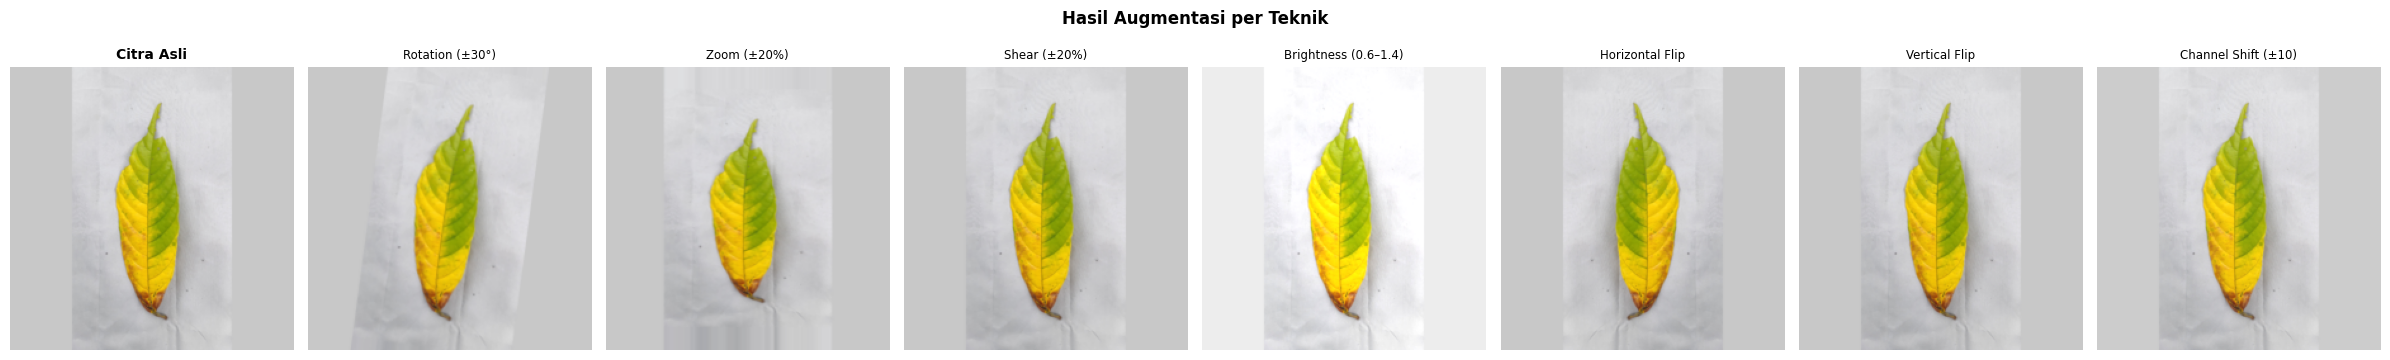

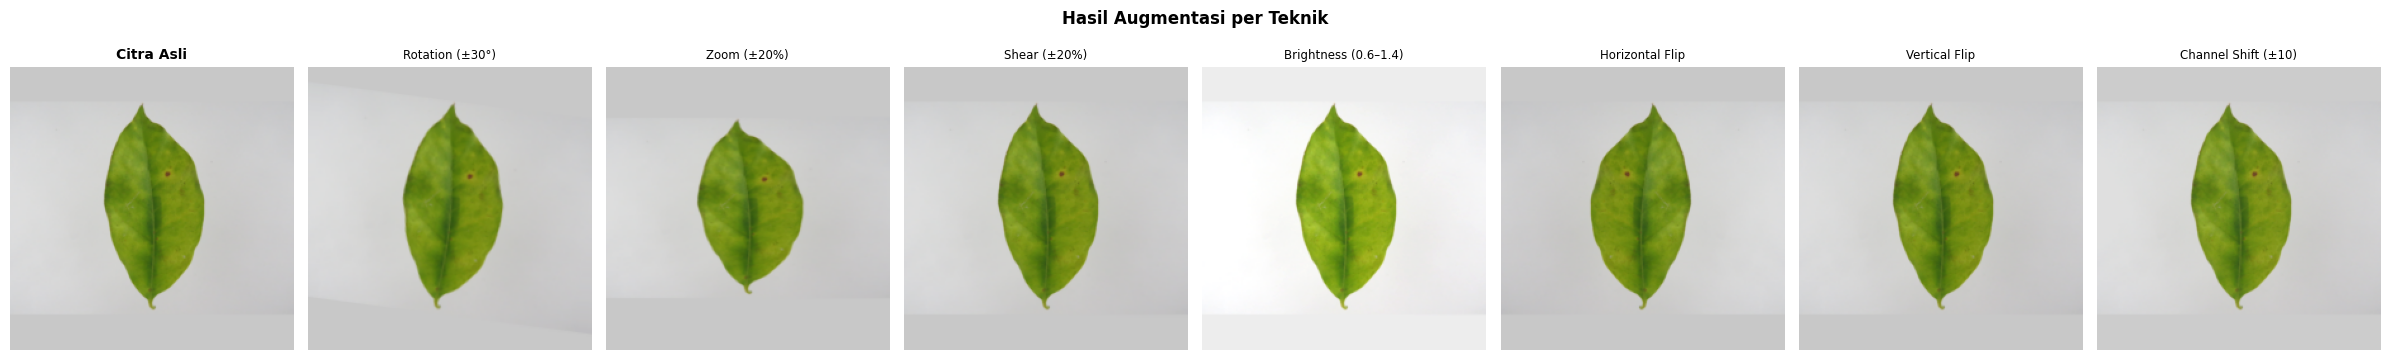

In [7]:
def visualize_per_technique(img_uint8, seed=42):
    TECHNIQUES = {
        "Rotation (±30°)": ImageDataGenerator(rotation_range=30, fill_mode="nearest"),
        "Zoom (±20%)": ImageDataGenerator(zoom_range=0.2, fill_mode="nearest"),
        "Shear (±20%)": ImageDataGenerator(shear_range=0.2, fill_mode="nearest"),
        "Brightness (0.6–1.4)": ImageDataGenerator(brightness_range=[0.6,1.4], fill_mode="nearest"),
        "Horizontal Flip": ImageDataGenerator(horizontal_flip=True, fill_mode="nearest"),
        "Vertical Flip": ImageDataGenerator(vertical_flip=True, fill_mode="nearest"),
        "Channel Shift (±10)": ImageDataGenerator(channel_shift_range=10.0, fill_mode="nearest"),
    }

    n_tech = len(TECHNIQUES)
    fig, axes = plt.subplots(1, n_tech + 1, figsize=(3 * (n_tech + 1), 3.5))

    axes[0].imshow(img_uint8)
    axes[0].set_title("Citra Asli", fontsize=10, fontweight="bold")
    axes[0].axis("off")

    for ax, (name, gen) in zip(axes[1:], TECHNIQUES.items()):
        aug_img = gen.random_transform(img_uint8.astype(np.float32), seed=seed)
        ax.imshow(np.clip(aug_img, 0, 255).astype(np.uint8))
        ax.set_title(name, fontsize=8.5)
        ax.axis("off")

    plt.suptitle("Hasil Augmentasi per Teknik", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


sample_img_1 = X224_train[2]
sample_img_2 = X224_train[1]
visualize_per_technique(sample_img_1, seed=CONFIG["SEED"])
visualize_per_technique(sample_img_2, seed=CONFIG["SEED"])

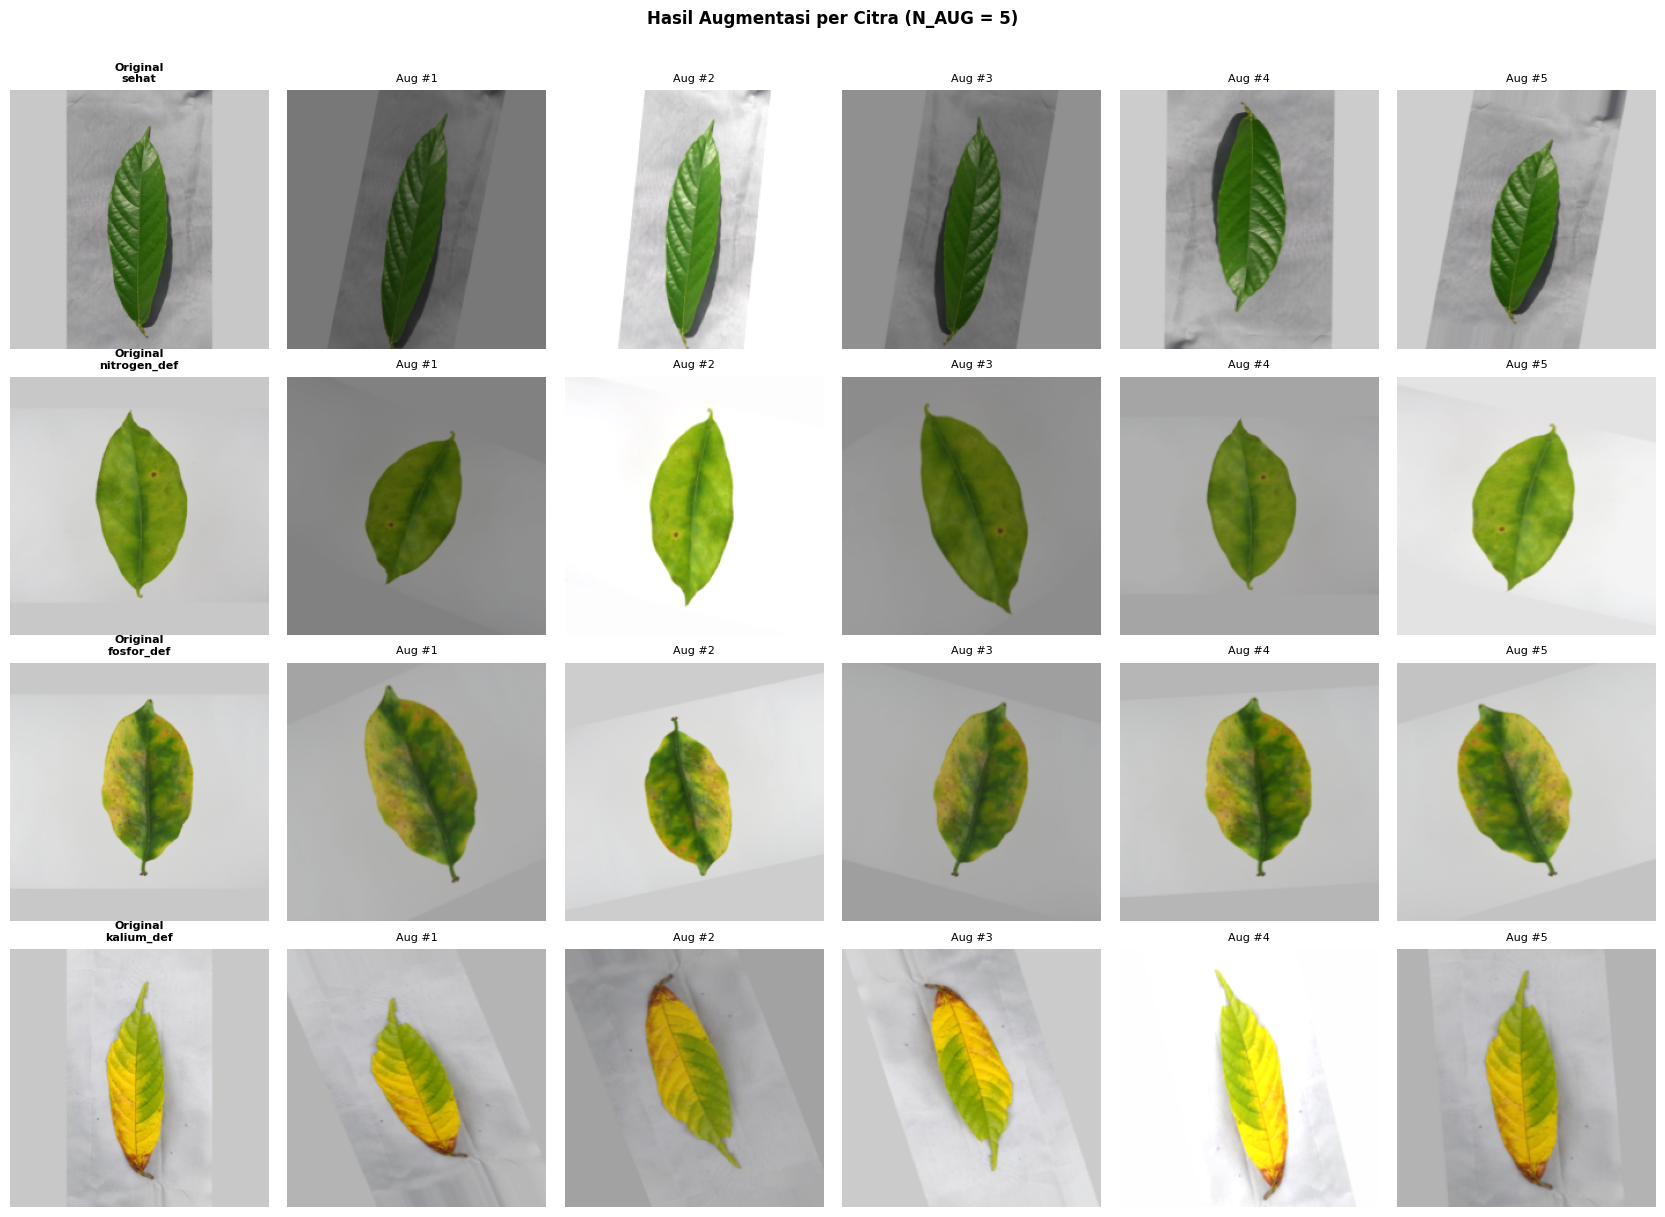

In [8]:
def visualize_n_aug(X, y, n_aug, classes, seed=42, sample_indices=None):
    rng = np.random.RandomState(seed)

    if sample_indices is None:
        sample_indices = []
        for cls_idx in range(len(classes)):
            idxs = np.where(y == cls_idx)[0]
            if len(idxs):
                sample_indices.append(idxs[0])

    n_rows = len(sample_indices)
    n_cols = n_aug + 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 3.0 * n_rows), squeeze=False)

    for row, idx in enumerate(sample_indices):
        img  = X[idx]
        label = classes[y[idx]]

        axes[row][0].imshow(img)
        axes[row][0].set_title("Original\n" + label, fontsize=8, fontweight="bold")
        axes[row][0].axis("off")

        for aug_i in range(n_aug):
            aug_seed = rng.randint(0, 99999)
            aug_img  = augmentor.random_transform(img.astype(np.float32), seed=aug_seed)
            axes[row][aug_i + 1].imshow(np.clip(aug_img, 0, 255).astype(np.uint8))
            axes[row][aug_i + 1].set_title(f"Aug #{aug_i + 1}", fontsize=8)
            axes[row][aug_i + 1].axis("off")

    plt.suptitle(
        f"Hasil Augmentasi per Citra (N_AUG = {n_aug})",
        fontsize=12, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()

visualize_n_aug(X224_train, y_train, n_aug=CONFIG["N_AUG"], classes=CONFIG["CLASSES"], seed=CONFIG["SEED"])

## Feature Extraction — 3 CNN

In [9]:
CNN_MODELS = [
    {"name": "ResNet50", "fn": ResNet50, "pre": pre_resnet, "size": 224, "X_train": None, "X_test": None},
    {"name": "VGG16", "fn": VGG16, "pre": pre_vgg, "size": 224, "X_train": None, "X_test": None},
    {"name": "InceptionV3", "fn": InceptionV3, "pre": pre_inception, "size": 299, "X_train": None, "X_test": None},
]

CNN_MODELS[0]["X_train"], CNN_MODELS[0]["X_test"] = X224_aug,  X224_test
CNN_MODELS[1]["X_train"], CNN_MODELS[1]["X_test"] = X224_aug,  X224_test
CNN_MODELS[2]["X_train"], CNN_MODELS[2]["X_test"] = X299_aug,  X299_test


def build_extractor(model_fn, img_size):
    base = model_fn(weights='imagenet', include_top=False,
                    input_shape=(img_size, img_size, 3))
    base.trainable = False
    out = GlobalAveragePooling2D()(base.output)
    return Model(inputs=base.input, outputs=out)


def extract_features(extractor, pre_fn, X, batch_size=16):
    X_pre = np.array([pre_fn(img) for img in X])
    return extractor.predict(X_pre, batch_size=batch_size, verbose=0)

In [10]:
F_train_list, F_test_list = [], []

for cfg in CNN_MODELS:
    print(f"Ekstraksi fitur: {cfg['name']}...")
    extractor = build_extractor(cfg["fn"], cfg["size"])

    F_train_list.append(extract_features(extractor, cfg["pre"], cfg["X_train"], CONFIG["BATCH_SIZE"]))
    F_test_list.append(extract_features(extractor, cfg["pre"], cfg["X_test"],  CONFIG["BATCH_SIZE"]))
    print(f"  Train: {F_train_list[-1].shape} | Test: {F_test_list[-1].shape}")

F_train = np.concatenate(F_train_list, axis=1)
F_test  = np.concatenate(F_test_list,  axis=1)
print(f"\nFitur gabungan  — Train: {F_train.shape} | Test: {F_test.shape}")

Ekstraksi fitur: ResNet50...


  Train: (720, 2048) | Test: (80, 2048)
Ekstraksi fitur: VGG16...
  Train: (720, 512) | Test: (80, 512)
Ekstraksi fitur: InceptionV3...
  Train: (720, 2048) | Test: (80, 2048)

Fitur gabungan  — Train: (720, 4608) | Test: (80, 4608)


In [11]:
feature_cols = [f"{i}" for i in range(F_train.shape[1])]
feat_df = pd.DataFrame(F_train, columns=feature_cols)
display(feat_df)

,0,1,2,3,4,5,6,7,8,9,...,4598,4599,4600,4601,4602,4603,4604,4605,4606,4607
0,2.517273,0.397326,1.522550,0.008728,0.100555,0.000000,0.246199,0.000000,0.009196,0.000000,...,0.000000,0.269911,0.145908,0.295618,0.000000,0.160946,0.567034,0.749798,0.015469,0.397181
1,2.880704,0.062841,0.458419,0.161983,0.000000,0.005774,0.012210,0.000000,0.000000,0.000000,...,0.161410,0.011622,0.261945,0.692706,0.045368,0.155891,0.689497,0.303940,0.516705,0.280001
2,2.095117,0.605265,0.787181,0.172183,0.001306,0.188742,0.039242,0.124396,0.079760,0.000000,...,0.392800,0.006378,0.495350,0.423627,0.000000,0.000000,1.142870,0.824356,0.042456,0.394231
3,3.165489,0.448433,0.462729,0.203816,0.000000,0.000000,0.000000,0.117568,0.145889,0.000000,...,0.136945,0.226794,0.486838,0.041037,0.028098,0.066135,0.487774,0.007048,0.718408,0.299239
4,3.297071,0.609782,1.255822,0.000000,0.000000,0.000000,0.300556,0.003194,0.000000,0.011467,...,0.087813,0.237363,0.126141,0.487063,0.006071,0.171085,0.409469,0.793743,0.564564,0.363715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,1.150445,0.429836,0.244773,0.000000,0.000000,0.320348,0.050798,0.000000,0.000000,0.000000,...,0.441566,0.388494,0.220933,1.529522,0.003325,0.668030,0.925549,1.054587,0.047123,0.123529
716,0.839716,0.884100,1.107371,0.003170,0.007490,0.642494,0.190170,0.007375,0.001993,0.000000,...,0.392896,0.987837,0.189127,0.400582,0.193119,0.141945,0.692921,0.465425,0.439779,0.868246
717,2.370053,0.368518,0.479951,0.374322,0.146662,1.098243,0.007485,0.020310,0.000000,0.000000,...,0.193707,0.748552,1.070208,0.527456,0.067257,0.335074,1.541388,0.234255,0.281973,0.167541
718,1.737002,0.070116,0.804374,0.000000,0.056388,0.015971,0.420122,0.515013,0.000000,0.101812,...,0.000000,0.177028,0.292561,0.043013,0.000000,0.857449,1.192363,0.388966,0.106573,0.386942


## Hyperparameter Tuning & Training SVM

In [12]:
pipeline = make_pipeline(
    StandardScaler(),
    OneVsRestClassifier(SVC(probability=True, random_state=CONFIG["SEED"]))
)

In [13]:
gs_kfold = GridSearchCV(
    estimator  = clone(pipeline),
    param_grid = CONFIG["PARAM_GRID"],
    cv         = 5,
    scoring    = "accuracy",
    n_jobs     = -1,
    verbose    = 1
)
gs_kfold.fit(F_train, y_aug)

y_pred_kfold   = gs_kfold.best_estimator_.predict(F_test)
test_acc_kfold = accuracy_score(y_test, y_pred_kfold)

print(f"\nParameter terbaik : {gs_kfold.best_params_}")
print(f"Akurasi validasi (CV) : {gs_kfold.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Parameter terbaik : {'onevsrestclassifier__estimator__C': 0.1, 'onevsrestclassifier__estimator__kernel': 'linear'}
Akurasi validasi (CV) : 0.9917


In [14]:
gs_kfold_df = pd.DataFrame(gs_kfold.cv_results_)
pd.set_option('display.max_colwidth', None)
gs_kfold_df[['params', 'mean_test_score', 'rank_test_score']]

,params,mean_test_score,rank_test_score
0,"{'onevsrestclassifier__estimator__C': 0.1, 'onevsrestclassifier__estimator__kernel': 'linear'}",0.991667,1
1,"{'onevsrestclassifier__estimator__C': 1, 'onevsrestclassifier__estimator__kernel': 'linear'}",0.991667,1
2,"{'onevsrestclassifier__estimator__C': 10, 'onevsrestclassifier__estimator__kernel': 'linear'}",0.991667,1
3,"{'onevsrestclassifier__estimator__C': 100, 'onevsrestclassifier__estimator__kernel': 'linear'}",0.991667,1
4,"{'onevsrestclassifier__estimator__C': 0.1, 'onevsrestclassifier__estimator__gamma': 0.001, 'onevsrestclassifier__estimator__kernel': 'rbf'}",0.826389,5
5,"{'onevsrestclassifier__estimator__C': 0.1, 'onevsrestclassifier__estimator__gamma': 0.01, 'onevsrestclassifier__estimator__kernel': 'rbf'}",0.302778,9
6,"{'onevsrestclassifier__estimator__C': 0.1, 'onevsrestclassifier__estimator__gamma': 0.1, 'onevsrestclassifier__estimator__kernel': 'rbf'}",0.250000,13
7,"{'onevsrestclassifier__estimator__C': 0.1, 'onevsrestclassifier__estimator__gamma': 1, 'onevsrestclassifier__estimator__kernel': 'rbf'}",0.250000,13
8,"{'onevsrestclassifier__estimator__C': 1, 'onevsrestclassifier__estimator__gamma': 0.001, 'onevsrestclassifier__estimator__kernel': 'rbf'}",0.819444,8
9,"{'onevsrestclassifier__estimator__C': 1, 'onevsrestclassifier__estimator__gamma': 0.01, 'onevsrestclassifier__estimator__kernel': 'rbf'}",0.302778,9


## Evaluasi Model

In [25]:
best_model = gs_kfold.best_estimator_
y_pred = best_model.predict(F_test)
print(classification_report(y_test, y_pred, target_names=CONFIG["CLASSES"]))

              precision    recall  f1-score   support

       sehat       1.00      1.00      1.00        20
nitrogen_def       0.76      0.95      0.84        20
  fosfor_def       0.89      0.80      0.84        20
  kalium_def       0.94      0.80      0.86        20

    accuracy                           0.89        80
   macro avg       0.90      0.89      0.89        80
weighted avg       0.90      0.89      0.89        80



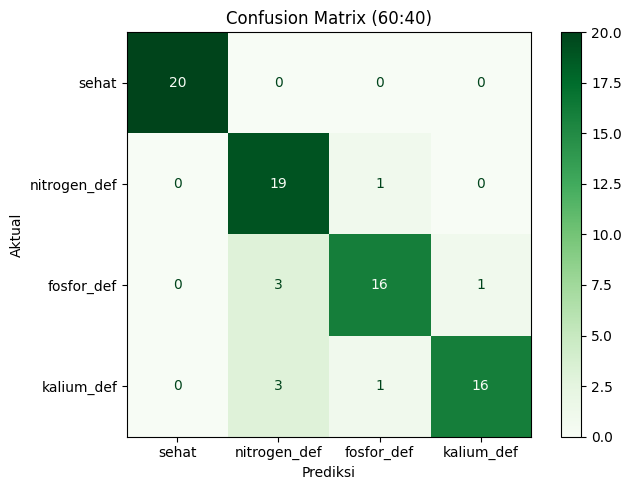

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=CONFIG["CLASSES"],
    cmap='Greens',
    ax=ax
)
ax.set_title("Confusion Matrix (60:40)")
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")
plt.tight_layout()

save_path = os.path.join(CONFIG["OUTPUT_DIR"], "confusion_matrix_6040.png")
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

In [17]:
file_names_test = [file_names[i] for i in idx_test]
proba = best_model.predict_proba(F_test)
confidence = proba.max(axis=1)

pred_df = pd.DataFrame({
    "file_name"  : file_names_test,
    "aktual"     : [CONFIG["CLASSES"][i] for i in y_test],
    "prediksi"   : [CONFIG["CLASSES"][i] for i in y_pred],
    "confidence" : [f"{c*100:.1f}%" for c in confidence],
})
pred_df["status"] = pred_df.apply(
    lambda r: "benar" if r["aktual"] == r["prediksi"] else "salah", axis=1
)

print(f"Total benar : {(pred_df['status'] == 'benar').sum()} / {len(pred_df)}")
print(f"Total salah : {(pred_df['status'] == 'salah').sum()} / {len(pred_df)}")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

pred_df

Total benar : 71 / 80
Total salah : 9 / 80


,file_name,aktual,prediksi,confidence,status
0,fosfor_def_(168)_jpg.rf.YLjjEjrsTYtsSb8HYyNW.jpg,fosfor_def,fosfor_def,80.5%,benar
1,sehat_IMG_20260509_095428_P4_D3.jpg,sehat,sehat,99.0%,benar
2,sehat_IMG_20260509_095442_P4_D4.jpg,sehat,sehat,99.6%,benar
3,nitrogen_def_(44)_jpg.rf.CWXKiLg8QNrvRA5FE83h.jpg,nitrogen_def,nitrogen_def,89.6%,benar
4,fosfor_def_(194)_jpg.rf.SeA0V06H0hfxJ6Fgx1si.jpg,fosfor_def,fosfor_def,99.8%,benar
5,sehat_IMG_20260511_173930_P6_D19.jpg,sehat,sehat,99.3%,benar
6,fosfor_def_(129)_jpg.rf.mXzU8sNMWFue39R7CzAP.jpg,fosfor_def,fosfor_def,81.8%,benar
7,fosfor_def_(136)_jpg.rf.qxSYeD6KOFJJr41OmAlp.jpg,fosfor_def,fosfor_def,99.4%,benar
8,kalium_def_IMG_20260517_102204_P11_D5.jpg,kalium_def,kalium_def,95.6%,benar
9,kalium_def_(68)_JPG.rf.Qq8as7JlOyBK5yH9tf6W.JPG,kalium_def,kalium_def,99.9%,benar


In [18]:
# import shutil

# OUTPUT_TEST_DIR = os.path.join(CONFIG["OUTPUT_DIR"], "test_images")
# os.makedirs(OUTPUT_TEST_DIR, exist_ok=True)

# for i in idx_test:
#     kelas = CONFIG["CLASSES"][y[i]]
#     src   = os.path.join(CONFIG["DATASET_DIR"], kelas, file_names[i])
#     dst   = os.path.join(OUTPUT_TEST_DIR, kelas, file_names[i])
#     os.makedirs(os.path.dirname(dst), exist_ok=True)
#     shutil.copy2(src, dst)

# print(f"{len(idx_test)} gambar disimpan → {OUTPUT_TEST_DIR}")
# for kelas in CONFIG["CLASSES"]:
#     n = sum(CONFIG["CLASSES"][y[i]] == kelas for i in idx_test)
#     print(f"  {kelas}: {n} gambar")

## Simpan Model

In [19]:
pipeline_path = os.path.join(CONFIG["OUTPUT_DIR"], "pipeline_cocoa.joblib")
joblib.dump(best_model, pipeline_path)
print(f"Pipeline disimpan: {pipeline_path}")

Pipeline disimpan: ../clf/output_6040/pipeline_cocoa.joblib


## Export SVM & Scaler ke JSON

In [20]:
# scaler = best_model.named_steps['standardscaler']
# svm    = best_model.named_steps['onevsrestclassifier']

# OUT = CONFIG["OUTPUT_DIR"]

# scaler_path = os.path.join(OUT, "scaler_params.json")
# with open(scaler_path, "w") as f:
#     json.dump({"mean": scaler.mean_.tolist(), "scale": scaler.scale_.tolist()}, f)
# print(f"scaler_params.json  ({os.path.getsize(scaler_path)/1024:.0f} KB)")

# kernel = svm.estimator.kernel
# coef_json      = [est.coef_.tolist()      for est in svm.estimators_]
# intercept_json = [est.intercept_.tolist() for est in svm.estimators_]
# svm_path = os.path.join(OUT, "svm_weights.json")
# with open(svm_path, "w") as f:
#     json.dump({
#         "kernel"   : kernel,
#         "C"        : svm.estimator.C,
#         "classes"  : svm.classes_.tolist(),
#         "labels"   : CONFIG["CLASSES"],
#         "coef"     : coef_json,
#         "intercept": intercept_json,
#     }, f)
# print(f"svm_weights.json    ({os.path.getsize(svm_path)/1024:.0f} KB)")

In [21]:
# def extract_features_tflite(tflite_path, pre_fn, X_uint8):
#     interpreter = tf.lite.Interpreter(model_path=tflite_path)
#     interpreter.allocate_tensors()
#     input_details  = interpreter.get_input_details()
#     output_details = interpreter.get_output_details()

#     features = []
#     for i in range(len(X_uint8)):
#         img_pre = pre_fn(X_uint8[i].astype(np.float32))
#         inp     = np.expand_dims(img_pre, axis=0).astype(np.float32)
#         interpreter.set_tensor(input_details[0]['index'], inp)
#         interpreter.invoke()
#         out = interpreter.get_tensor(output_details[0]['index'])
#         features.append(out[0])
#     return np.array(features)


# TFLITE_CNN_CFG = [
#     ("resnet50",    pre_resnet,    X224_test),
#     ("vgg16",       pre_vgg,       X224_test),
#     ("inceptionv3", pre_inception, X299_test),
# ]

# QUANTIZATION_METHODS = ["float16", "dynamic_int8", "full_int8"]

# print(f"{'Metode':<16} {'Akurasi':>9} {'Presisi':>9} {'Recall':>9} {'F1-Score':>9}")
# print("-" * 57)

# results_tflite = {}

# for method in QUANTIZATION_METHODS:
#     F_test_tflite_list = []
#     for cnn_name, pre_fn, X_test_cnn in TFLITE_CNN_CFG:
#         tflite_path = os.path.join("../clf/export_tflite", f"{cnn_name}_{method}.tflite")
#         feats = extract_features_tflite(tflite_path, pre_fn, X_test_cnn)
#         F_test_tflite_list.append(feats)

#     F_test_tflite = np.concatenate(F_test_tflite_list, axis=1)

#     y_pred_tflite = best_model.predict(F_test_tflite)

#     acc  = accuracy_score(y_test,  y_pred_tflite)
#     prec = precision_score(y_test, y_pred_tflite, average='weighted', zero_division=0)
#     rec  = recall_score(y_test,    y_pred_tflite, average='weighted', zero_division=0)
#     f1   = f1_score(y_test,        y_pred_tflite, average='weighted', zero_division=0)

#     results_tflite[method] = dict(accuracy=acc, precision=prec, recall=rec, f1=f1,
#                                   y_pred=y_pred_tflite)

#     print(f"{method:<16} {acc:>9.4f} {prec:>9.4f} {rec:>9.4f} {f1:>9.4f}")